# PS3 Deep Learning V-Residual Solver

This notebook solves the two-state consumption-saving problem by approximating the **value function**
\(V(a,n)\) with a neural network, following Algorithm 1 from the assignment.

Pipeline:
1. Sample from state space \((a,n)\)
2. Warm-start by fitting \(V_0(a,n)=\rho^{-1}(wn+ra)^{1-\gamma}/(1-\gamma)\)
3. Train on the HJB residual in \(V\) (Algorithm 1)

In [53]:
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import random, value_and_grad
from jax import tree_util

from scipy.sparse import diags, identity, block_diag, kron
from scipy.sparse.linalg import spsolve
from scipy.integrate import cumulative_trapezoid

np.set_printoptions(precision=4, suppress=True)
print("JAX version:", jax.__version__)

JAX version: 0.9.0.1


## Step 2 — Parameters and grid

- **a_bar** = 1e-6: hard borrowing limit (grid starts here).
- **alb** = 1.0: penalty threshold. Augmented utility is U(a,c) = u(c) + **1_{a ≤ alb}** ψ(a) with ψ(a) = −½κ(a−alb)², so the penalty is active for all a in **[a_bar, alb]**. Using alb (not a_bar) lets the DL solver “see” the penalty on a nontrivial part of the grid.

In [54]:

n1 = 0.3
lambda_vals = np.array([0.4, 0.4])
n2 = 1.0 + (lambda_vals[1] / lambda_vals[0]) * (1.0 - n1)

params = {
    "alpha": 1.0 / 3.0,
    "delta": 0.1,
    "z": 1.0,
    "gamma": 2.1,
    "rho": 0.05,
    "r": 0.06,
    "w": 1.0,
    "n_vals": np.array([n1, n2]),
    "lambda_vals": lambda_vals,
    "a_bar": 1e-6,
    "a_max": 20.0,
    "alb": 0.5,
    "kappa": 3.0,
    "N_a": 400,
    "Delta": 100.0,
    "max_iter": 1000,
    "tol": 1e-7,
    "damping": 0.9,
}

a_grid = np.linspace(params["a_bar"], params["a_max"], params["N_a"])
Lambda = np.array([
    [-params["lambda_vals"][0], params["lambda_vals"][0]],
    [params["lambda_vals"][1], -params["lambda_vals"][1]],
])

print("n_vals:", params["n_vals"])
print("a-range:", (params["a_bar"], params["a_max"]))

n_vals: [0.3 1.7]
a-range: (1e-06, 20.0)


## Step 3 — State-space sampler

Draw M points (a,n): a ∼ Uniform(a_bar, a_max), n ∈ {n₁, n₂} with stationary probabilities. Used as collocation points in Algorithm 1 step 3(a).

In [55]:
def u(c, gamma):
    c_safe = np.maximum(c, 1e-12)
    if abs(gamma - 1.0) < 1e-12:
        return np.log(c_safe)
    return c_safe ** (1.0 - gamma) / (1.0 - gamma)


def u_jax(c, gamma):
    """CRRA utility in JAX for HJB residual."""
    c_safe = jnp.maximum(c, 1e-12)
    return c_safe ** (1.0 - gamma) / (1.0 - gamma)


def u_prime_inv(mu, gamma):
    mu_safe = jnp.maximum(mu, 1e-12)
    return mu_safe ** (-1.0 / gamma)


def V_target(a, n, p):
    """Warm-start target: V_0(a,n) = rho^{-1} (wn+ra)^{1-gamma}/(1-gamma)."""
    flow = p["w"] * n + p["r"] * a
    flow = jnp.maximum(flow, 1e-12)
    return (1.0 / p["rho"]) * (flow ** (1.0 - p["gamma"]) / (1.0 - p["gamma"]))


def psi(a, p):
    """Penalty level: psi(a) = -0.5 * kappa * (a - alb)^2 (used in HJB in V)."""
    return -0.5 * p["kappa"] * (a - p["alb"]) ** 2





p_jax = {
    "gamma": jnp.array(params["gamma"]),
    "rho": jnp.array(params["rho"]),
    "r": jnp.array(params["r"]),
    "w": jnp.array(params["w"]),
    "a_bar": jnp.array(params["a_bar"]),
    "a_max": jnp.array(params["a_max"]),
    "alb": jnp.array(params["alb"]),
    "kappa": jnp.array(params["kappa"]),
    "n1": jnp.array(params["n_vals"][0]),
    "n2": jnp.array(params["n_vals"][1]),
    "lam1": jnp.array(params["lambda_vals"][0]),
    "lam2": jnp.array(params["lambda_vals"][1]),
}

## Step 4 — Network for V(a,n)

MLP input (a,n), output \(\hat{V}(a,n)\). We need \(\partial_a \hat{V}\) for the HJB (drift term and \(c^*=u'^{-1}(\partial_a V)\)). JAX autodiff gives \(\partial_a \hat{V}\).

In [56]:
def sample_state_batch(
    key,
    M,
    p,
    stationary=True,
    boundary_frac=0.0,
    balanced_n=False,
):
    key_a, key_n, key_mix, key_a_boundary = random.split(key, 4)

    # Optional mixture sampling to oversample the [a_bar, alb] region.
    a_uniform = random.uniform(
        key_a,
        shape=(M,),
        minval=p["a_bar"],
        maxval=p["a_max"],
    )
    a_boundary = random.uniform(
        key_a_boundary,
        shape=(M,),
        minval=p["a_bar"],
        maxval=p["alb"],
    )
    use_boundary = random.bernoulli(key_mix, p=boundary_frac, shape=(M,))
    a = jnp.where(use_boundary, a_boundary, a_uniform)

    if balanced_n:
        # Force roughly half low/high state each batch.
        is_low = random.bernoulli(key_n, p=0.5, shape=(M,))
    else:
        if stationary:
            # Stationary probability for low state in two-state CTMC.
            p_low = p["lam2"] / (p["lam1"] + p["lam2"])
        else:
            p_low = 0.5
        is_low = random.bernoulli(key_n, p=p_low, shape=(M,))

    n = jnp.where(is_low, p["n1"], p["n2"])
    return a, n


key = random.PRNGKey(985)
a_s, n_s = sample_state_batch(key, M=8, p=p_jax, stationary=True)
print("sample a:", a_s)
print("sample n:", n_s)

sample a: [ 2.4599  6.0051 15.4993  6.899  13.4233  7.6727  1.6579 10.6335]
sample n: [1.7 0.3 1.7 0.3 0.3 0.3 0.3 0.3]


## Step 5 — Losses and HJB residual in V

- **HJB**: 0 = −ρV + u(c*) + **1_{a≤alb} ψ(a)** + ∂_a V·(wn+ra−c*) + λ(n)(V(a,n̄)−V(a,n)), with c* = u'⁻¹(∂_a V).  
- **Penalty**: ψ(a) = −½κ(a−alb)²; we use **alb** so the penalty is active on [a_bar, alb].  
- **warmstart_loss**: MSE between V̂ and V₀(a,n) = ρ⁻¹(wn+ra)^{1−γ}/(1−γ).  
- **pde_loss**: mean squared HJB residual over a batch.

In [57]:
def init_mlp(key, layer_sizes):
    params = []
    keys = random.split(key, len(layer_sizes) - 1)
    for k, (m, n) in zip(keys, zip(layer_sizes[:-1], layer_sizes[1:])):
        w_key, _ = random.split(k)
        W = random.normal(w_key, (m, n)) * jnp.sqrt(2.0 / m)
        b = jnp.zeros((n,))
        params.append((W, b))
    return params


def mlp_forward_V(params, x):
    """MLP that outputs V (no positivity constraint)."""
    h = x
    for W, b in params[:-1]:
        h = jnp.tanh(h @ W + b)
    W_last, b_last = params[-1]
    return (h @ W_last + b_last).squeeze(-1)


def normalize_inputs(a, n, p):
    a_norm = (a - p["a_bar"]) / (p["a_max"] - p["a_bar"])
    n_norm = (n - p["n1"]) / (p["n2"] - p["n1"])
    return a_norm, n_norm


def V_hat(theta, a, n):
    """Value function approximation V(a,n)."""
    a_norm, n_norm = normalize_inputs(a, n, p_jax)
    x = jnp.stack([a_norm, n_norm], axis=-1)
    return mlp_forward_V(theta, x)


def V_hat_scalar(theta, a, n):
    return V_hat(theta, jnp.array([a]), jnp.array([n]))[0]


def lambda_of_n(n, p):
    return jnp.where(jnp.isclose(n, p["n1"]), p["lam1"], p["lam2"])


def n_complement(n, p):
    return jnp.where(jnp.isclose(n, p["n1"]), p["n2"], p["n1"])


layer_sizes = [2, 64, 64, 64, 1]
key, key_model = random.split(key)
theta0 = init_mlp(key_model, layer_sizes)

a_probe = jnp.array([p_jax["a_bar"]])
n_probe = jnp.array([p_jax["n1"]])
print("Initialized MLP with", len(theta0), "layers (outputs V)")
print("Sample V_hat(a_bar,n1):", float(V_hat(theta0, a_probe, n_probe)[0]))

Initialized MLP with 4 layers (outputs V)
Sample V_hat(a_bar,n1): 0.0


## Step 6 — Adam optimizer

Standard Adam (m, v, bias-corrected) for updating θ. Used in both warm-start and PDE training.

In [58]:
def mse(x):
    return jnp.mean(jnp.square(x))


def warmstart_loss(theta, a, n, p):
    pred = V_hat(theta, a, n)
    tgt = V_target(a, n, p)
    return mse(pred - tgt)


def hjb_residual(theta, a, n, p):
    """HJB residual: 0 = -rho*V + u(c*) + 1_{a<=alb}*psi(a) + Va*(wn+ra-c*) + lambda*(V_other-V)."""
    V = V_hat(theta, a, n)

    x = jnp.stack([a, n], axis=-1)
    grad_wrt_x = jax.vmap(
        jax.grad(lambda xi: V_hat_scalar(theta, xi[0], xi[1]))
    )(x)
    Va = grad_wrt_x[:, 0]

    c_star = u_prime_inv(jnp.maximum(Va, 1e-12), p["gamma"])
    drift = p["w"] * n + p["r"] * a - c_star

    n_other = n_complement(n, p)
    V_other = V_hat(theta, a, n_other)
    lam_n = lambda_of_n(n, p)

    penalty_mask = (a <= p["alb"]).astype(a.dtype)
    penalty_term = penalty_mask * psi(a, p)

    res = (
        -p["rho"] * V
        + u_jax(c_star, p["gamma"])
        + penalty_term
        + Va * drift
        + lam_n * (V_other - V)
    )
    return res


def pde_loss(theta, a, n, p):
    return mse(hjb_residual(theta, a, n, p))

In [59]:
# Train DL solver with a_lb = 1 for second comparison (theta_star is for a_lb = 0.5)
theta_star_alb05 = theta_star  # keep current solution for alb=0.5
p_jax_alb1 = {**p_jax, "alb": jnp.array(1.0)}
key, key_w1, key_c1, key_p1 = random.split(key, 4)
theta0_alb1 = init_mlp(random.PRNGKey(4321), layer_sizes)
theta_warm_1, _, key = train_warmstart(theta0_alb1, p_jax_alb1, key_w1)
theta_curr_1, _, key = train_curriculum(theta_warm_1, p_jax_alb1, key_c1)
theta_star_alb1, _, key = train_pde(theta_curr_1, p_jax_alb1, key_p1)

warm-start step=   1 lr=2.00e-03 loss=4.122e+02
warm-start step= 250 lr=1.88e-03 loss=4.408e+01
warm-start step= 500 lr=1.55e-03 loss=6.597e-01
warm-start step= 750 lr=1.10e-03 loss=3.607e-02
warm-start step=1000 lr=6.51e-04 loss=3.900e-03
warm-start step=1250 lr=3.21e-04 loss=1.489e-03
warm-start step=1500 lr=2.00e-04 loss=1.799e-03
curriculum step=   1 alpha=1.00 lr=1.00e-03 loss=5.003e-03
curriculum step= 200 alpha=0.75 lr=8.98e-04 loss=2.284e+01
curriculum step= 400 alpha=0.50 lr=6.51e-04 loss=1.439e+03
curriculum step= 600 alpha=0.25 lr=4.03e-04 loss=2.739e+01
curriculum step= 800 alpha=0.00 lr=3.00e-04 loss=2.138e-01
pde step=   1 lr=1.00e-03 loss=2.173e-01
pde step= 500 lr=9.94e-04 loss=2.954e-04
pde step=1000 lr=9.76e-04 loss=3.339e-05
pde step=1500 lr=9.46e-04 loss=1.117e-04
pde step=2000 lr=9.06e-04 loss=5.716e-05
pde step=2500 lr=8.55e-04 loss=2.695e-04
pde step=3000 lr=7.96e-04 loss=1.363e-05
pde step=3500 lr=7.30e-04 loss=1.428e-05
pde step=4000 lr=6.58e-04 loss=2.635e-05


## Step 7 — Training loop (with curriculum)

1. **Warm-start**: fit MSE(V̂, V₀) with JIT-compiled Adam and cosine LR decay.  
2. **Curriculum bridge**: optimize `alpha * warmstart_loss + (1 - alpha) * pde_loss`, with `alpha` decaying from 1 to 0.  
3. **PDE phase**: minimize mean squared HJB residual in V (JIT, cosine LR, gradient clipping, boundary oversampling near constraints).

In [60]:
def tree_zeros_like(tree):
    return tree_util.tree_map(jnp.zeros_like, tree)


def adam_init(params):
    return {
        "m": tree_zeros_like(params),
        "v": tree_zeros_like(params),
        "t": jnp.array(0),
    }


def tree_l2_norm(tree):
    sq_sum = tree_util.tree_reduce(
        lambda acc, x: acc + jnp.sum(jnp.square(x)),
        tree,
        initializer=jnp.array(0.0),
    )
    return jnp.sqrt(sq_sum)


def maybe_clip_grads(grads, clip_grad_norm=None):
    if clip_grad_norm is None:
        return grads
    g_norm = tree_l2_norm(grads)
    scale = jnp.minimum(1.0, clip_grad_norm / (g_norm + 1e-12))
    return tree_util.tree_map(lambda g: g * scale, grads)


def adam_update(
    params,
    grads,
    state,
    lr=1e-3,
    b1=0.9,
    b2=0.999,
    eps=1e-8,
    clip_grad_norm=None,
    weight_decay=0.0,
):
    grads = maybe_clip_grads(grads, clip_grad_norm=clip_grad_norm)

    t = state["t"] + 1
    m = tree_util.tree_map(lambda m_, g_: b1 * m_ + (1.0 - b1) * g_, state["m"], grads)
    v = tree_util.tree_map(lambda v_, g_: b2 * v_ + (1.0 - b2) * (g_ * g_), state["v"], grads)

    mhat = tree_util.tree_map(lambda m_: m_ / (1.0 - b1 ** t), m)
    vhat = tree_util.tree_map(lambda v_: v_ / (1.0 - b2 ** t), v)

    # AdamW-style decoupled weight decay.
    new_params = tree_util.tree_map(
        lambda p_, m_, v_: p_ - lr * (m_ / (jnp.sqrt(v_) + eps) + weight_decay * p_),
        params,
        mhat,
        vhat,
    )

    new_state = {"m": m, "v": v, "t": t}
    return new_params, new_state

In [61]:
def cosine_lr(step, n_steps, lr_max, lr_min=0.0):
    if n_steps <= 1:
        return lr_min
    frac = (step - 1) / (n_steps - 1)
    return lr_min + 0.5 * (lr_max - lr_min) * (1.0 + np.cos(np.pi * frac))


def train_warmstart(
    theta_init,
    p,
    key,
    n_steps=1500,
    batch_size=2048,
    lr_max=2e-3,
    lr_min=2e-4,
    clip_grad_norm=1.0,
    weight_decay=0.0,
):
    theta = theta_init
    opt_state = adam_init(theta)
    hist = []

    @jax.jit
    def warm_step(theta, opt_state, key, lr):
        key, key_batch = random.split(key)
        a_b, n_b = sample_state_batch(
            key_batch,
            batch_size,
            p,
            stationary=True,
            boundary_frac=0.0,
            balanced_n=True,
        )
        loss_val, grads = value_and_grad(warmstart_loss)(theta, a_b, n_b, p)
        theta, opt_state = adam_update(
            theta,
            grads,
            opt_state,
            lr=lr,
            clip_grad_norm=clip_grad_norm,
            weight_decay=weight_decay,
        )
        return theta, opt_state, key, loss_val

    for step in range(1, n_steps + 1):
        lr = cosine_lr(step, n_steps, lr_max=lr_max, lr_min=lr_min)
        theta, opt_state, key, loss_val = warm_step(theta, opt_state, key, lr)
        hist.append(float(loss_val))

        if step % 250 == 0 or step == 1:
            print(f"warm-start step={step:4d} lr={lr:.2e} loss={loss_val:.3e}")

    return theta, np.array(hist), key


def train_curriculum(
    theta_init,
    p,
    key,
    n_steps=800,
    batch_size=2048,
    lr_max=1e-3,
    lr_min=3e-4,
    boundary_frac=0.2,
    balanced_n=True,
    clip_grad_norm=1.0,
    weight_decay=1e-6,
):
    theta = theta_init
    opt_state = adam_init(theta)
    hist = []

    def curriculum_loss(theta, a, n, p, alpha):
        return alpha * warmstart_loss(theta, a, n, p) + (1.0 - alpha) * pde_loss(theta, a, n, p)

    @jax.jit
    def curriculum_step(theta, opt_state, key, lr, alpha):
        key, key_batch = random.split(key)
        a_b, n_b = sample_state_batch(
            key_batch,
            batch_size,
            p,
            stationary=True,
            boundary_frac=boundary_frac,
            balanced_n=balanced_n,
        )
        loss_val, grads = value_and_grad(curriculum_loss)(theta, a_b, n_b, p, alpha)
        theta, opt_state = adam_update(
            theta,
            grads,
            opt_state,
            lr=lr,
            clip_grad_norm=clip_grad_norm,
            weight_decay=weight_decay,
        )
        return theta, opt_state, key, loss_val

    for step in range(1, n_steps + 1):
        alpha = 1.0 - (step - 1) / max(1, n_steps - 1)
        lr = cosine_lr(step, n_steps, lr_max=lr_max, lr_min=lr_min)
        theta, opt_state, key, loss_val = curriculum_step(theta, opt_state, key, lr, alpha)
        hist.append(float(loss_val))

        if step % 200 == 0 or step == 1:
            print(
                f"curriculum step={step:4d} alpha={alpha:.2f} "
                f"lr={lr:.2e} loss={loss_val:.3e}"
            )

    return theta, np.array(hist), key


def train_pde(
    theta_init,
    p,
    key,
    n_steps=10000,
    batch_size=2048,
    lr_max=1e-3,
    lr_min=1e-5,
    boundary_frac=0.3,
    balanced_n=True,
    clip_grad_norm=1.0,
    weight_decay=1e-6,
):
    theta = theta_init
    opt_state = adam_init(theta)
    hist = []

    @jax.jit
    def pde_step(theta, opt_state, key, lr):
        key, key_batch = random.split(key)
        a_b, n_b = sample_state_batch(
            key_batch,
            batch_size,
            p,
            stationary=True,
            boundary_frac=boundary_frac,
            balanced_n=balanced_n,
        )
        loss_val, grads = value_and_grad(pde_loss)(theta, a_b, n_b, p)
        theta, opt_state = adam_update(
            theta,
            grads,
            opt_state,
            lr=lr,
            clip_grad_norm=clip_grad_norm,
            weight_decay=weight_decay,
        )
        return theta, opt_state, key, loss_val

    for step in range(1, n_steps + 1):
        lr = cosine_lr(step, n_steps, lr_max=lr_max, lr_min=lr_min)
        theta, opt_state, key, loss_val = pde_step(theta, opt_state, key, lr)
        hist.append(float(loss_val))

        if step % 500 == 0 or step == 1:
            print(f"pde step={step:4d} lr={lr:.2e} loss={loss_val:.3e}")

    return theta, np.array(hist), key


key, key_warm, key_curr, key_pde = random.split(key, 4)
theta_warm, warm_hist, key = train_warmstart(theta0, p_jax, key_warm)
theta_curr, curr_hist, key = train_curriculum(theta_warm, p_jax, key_curr)
theta_star, pde_hist, key = train_pde(theta_curr, p_jax, key_pde)

print("Warm-start final loss:", warm_hist[-1])
print("Curriculum final loss:", curr_hist[-1])
print("PDE final loss:", pde_hist[-1])

warm-start step=   1 lr=2.00e-03 loss=4.630e+02
warm-start step= 250 lr=1.88e-03 loss=4.677e+01
warm-start step= 500 lr=1.55e-03 loss=7.480e-01
warm-start step= 750 lr=1.10e-03 loss=3.811e-02
warm-start step=1000 lr=6.51e-04 loss=4.253e-03
warm-start step=1250 lr=3.21e-04 loss=2.837e-03
warm-start step=1500 lr=2.00e-04 loss=1.529e-03
curriculum step=   1 alpha=1.00 lr=1.00e-03 loss=1.784e-02
curriculum step= 200 alpha=0.75 lr=8.98e-04 loss=2.432e+01
curriculum step= 400 alpha=0.50 lr=6.51e-04 loss=3.581e+01
curriculum step= 600 alpha=0.25 lr=4.03e-04 loss=3.081e+01
curriculum step= 800 alpha=0.00 lr=3.00e-04 loss=1.841e-01
pde step=   1 lr=1.00e-03 loss=1.889e-01
pde step= 500 lr=9.94e-04 loss=8.747e-05
pde step=1000 lr=9.76e-04 loss=6.539e-05
pde step=1500 lr=9.46e-04 loss=1.911e-05
pde step=2000 lr=9.06e-04 loss=3.841e-05
pde step=2500 lr=8.55e-04 loss=3.722e-05
pde step=3000 lr=7.96e-04 loss=1.062e-05
pde step=3500 lr=7.30e-04 loss=1.232e-05
pde step=4000 lr=6.58e-04 loss=1.972e-05


## Consumption policy and value function (FD vs DL)

Single figure: left = consumption c(a,n), right = value V(a,n). Both methods on the same axes (dashed = FD, solid = DL).

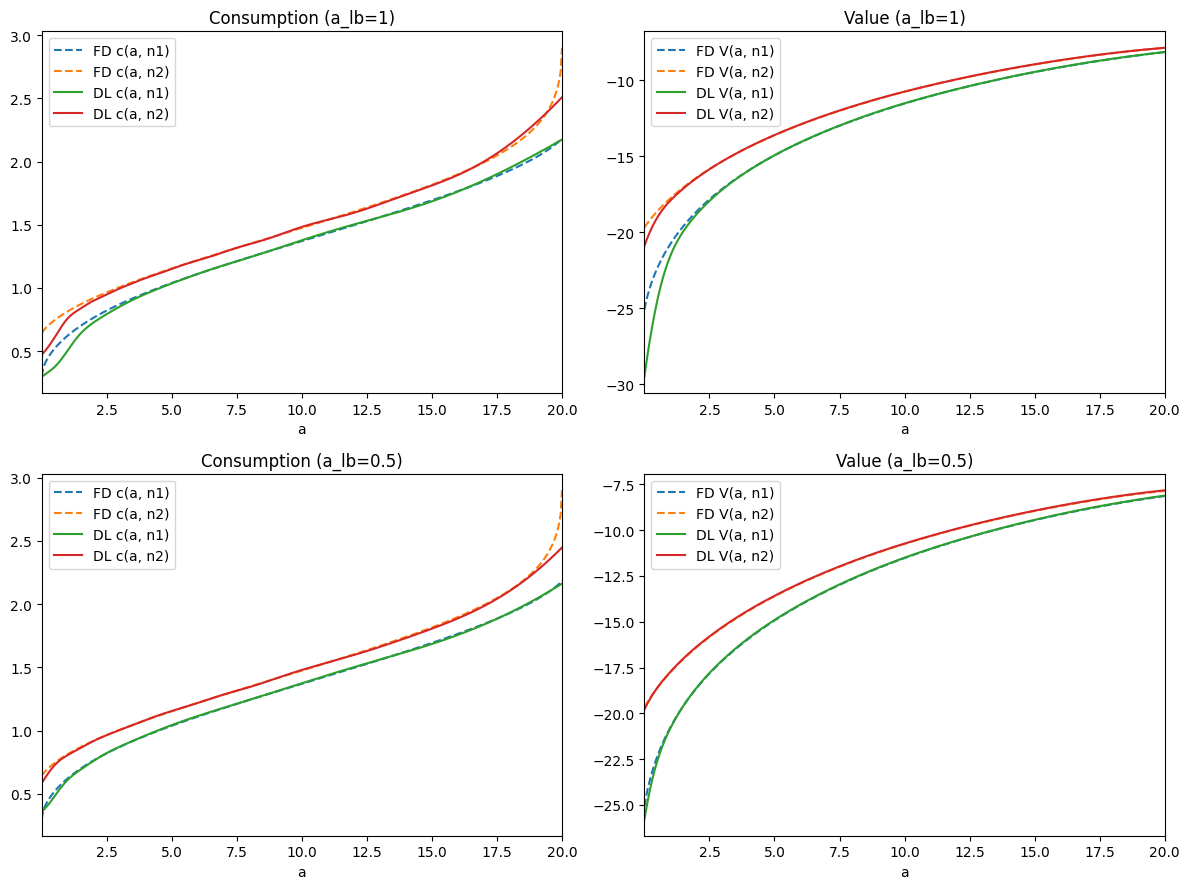

In [62]:
# Combined plot: FD vs DL for a_lb=1 (top row) and a_lb=0.5 (bottom row)
from importlib.util import module_from_spec, spec_from_file_location
from pathlib import Path
for candidate in [Path("fd_hard_constraint_solver.py"), Path("ECO 529 2025 - Problem Set 3") / "fd_hard_constraint_solver.py"]:
    if candidate.exists():
        fd_spec = spec_from_file_location("fd_hard_constraint_solver", candidate)
        fd_module = module_from_spec(fd_spec)
        fd_spec.loader.exec_module(fd_module)
        break
else:
    raise FileNotFoundError("Could not find fd_hard_constraint_solver.py")

params_alb1 = {**params, "alb": 1.0}
params_alb05 = {**params, "alb": 0.5}
fd_result_alb1 = fd_module.solve_fd_hard_constraint(params_alb1, a_grid=a_grid)
fd_result_alb05 = fd_module.solve_fd_hard_constraint(params_alb05, a_grid=a_grid)

a_eval = jnp.asarray(a_grid)
n1_eval = jnp.full_like(a_eval, p_jax["n1"])
n2_eval = jnp.full_like(a_eval, p_jax["n2"])

def Va_on_grid(theta, a_vals, n_vals):
    x = jnp.stack([a_vals, n_vals], axis=-1)
    grad_fn = jax.vmap(jax.grad(lambda xi: V_hat_scalar(theta, xi[0], xi[1])))
    return grad_fn(x)[:, 0]

def dl_curves(theta):
    Va_n1 = np.array(Va_on_grid(theta, a_eval, n1_eval))
    Va_n2 = np.array(Va_on_grid(theta, a_eval, n2_eval))
    c_n1 = np.array(u_prime_inv(jnp.maximum(jnp.asarray(Va_n1), 1e-12), p_jax["gamma"]))
    c_n2 = np.array(u_prime_inv(jnp.maximum(jnp.asarray(Va_n2), 1e-12), p_jax["gamma"]))
    V_n1 = np.array(V_hat(theta, a_eval, n1_eval))
    V_n2 = np.array(V_hat(theta, a_eval, n2_eval))
    return c_n1, c_n2, V_n1, V_n2

c_dl_1_n1, c_dl_1_n2, V_dl_1_n1, V_dl_1_n2 = dl_curves(theta_star_alb1)
c_dl_05_n1, c_dl_05_n2, V_dl_05_n1, V_dl_05_n2 = dl_curves(theta_star_alb05)

c_fd_1_n1 = np.asarray(fd_result_alb1["c"][0])
c_fd_1_n2 = np.asarray(fd_result_alb1["c"][1])
V_fd_1_n1 = np.asarray(fd_result_alb1["V_n1"])
V_fd_1_n2 = np.asarray(fd_result_alb1["V_n2"])
c_fd_05_n1 = np.asarray(fd_result_alb05["c"][0])
c_fd_05_n2 = np.asarray(fd_result_alb05["c"][1])
V_fd_05_n1 = np.asarray(fd_result_alb05["V_n1"])
V_fd_05_n2 = np.asarray(fd_result_alb05["V_n2"])

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
# Row 0: a_lb = 1
ax1, ax2 = axes[0, 0], axes[0, 1]
ax1.plot(a_grid, c_fd_1_n1, "--", label="FD c(a, n1)")
ax1.plot(a_grid, c_fd_1_n2, "--", label="FD c(a, n2)")
ax1.plot(a_grid, c_dl_1_n1, "-", label="DL c(a, n1)")
ax1.plot(a_grid, c_dl_1_n2, "-", label="DL c(a, n2)")
ax1.set_title("Consumption (a_lb=1)")
ax1.set_xlabel("a")
ax1.legend()
ax1.set_xlim(a_grid[0], a_grid[-1])
ax2.plot(a_grid, V_fd_1_n1, "--", label="FD V(a, n1)")
ax2.plot(a_grid, V_fd_1_n2, "--", label="FD V(a, n2)")
ax2.plot(a_grid, V_dl_1_n1, "-", label="DL V(a, n1)")
ax2.plot(a_grid, V_dl_1_n2, "-", label="DL V(a, n2)")
ax2.set_title("Value (a_lb=1)")
ax2.set_xlabel("a")
ax2.legend()
ax2.set_xlim(a_grid[0], a_grid[-1])
# Row 1: a_lb = 0.5
ax3, ax4 = axes[1, 0], axes[1, 1]
ax3.plot(a_grid, c_fd_05_n1, "--", label="FD c(a, n1)")
ax3.plot(a_grid, c_fd_05_n2, "--", label="FD c(a, n2)")
ax3.plot(a_grid, c_dl_05_n1, "-", label="DL c(a, n1)")
ax3.plot(a_grid, c_dl_05_n2, "-", label="DL c(a, n2)")
ax3.set_title("Consumption (a_lb=0.5)")
ax3.set_xlabel("a")
ax3.legend()
ax3.set_xlim(a_grid[0], a_grid[-1])
ax4.plot(a_grid, V_fd_05_n1, "--", label="FD V(a, n1)")
ax4.plot(a_grid, V_fd_05_n2, "--", label="FD V(a, n2)")
ax4.plot(a_grid, V_dl_05_n1, "-", label="DL V(a, n1)")
ax4.plot(a_grid, V_dl_05_n2, "-", label="DL V(a, n2)")
ax4.set_title("Value (a_lb=0.5)")
ax4.set_xlabel("a")
ax4.legend()
ax4.set_xlim(a_grid[0], a_grid[-1])
plt.tight_layout()
